<a href="https://www.kaggle.com/code/aamir28/how-nations-compare-217-countries?scriptVersionId=338704272" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


<div style="background:linear-gradient(135deg,#0D2B3E 0%,#123A52 100%); padding:44px 40px; border-radius:8px; border:1px solid #D4AF37; font-family:Georgia,'Times New Roman',serif;">

  <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:6px;">
    <span style="font-family:'Courier New',monospace; letter-spacing:3px; font-size:11px; color:#D4AF37; text-transform:uppercase;">◆ The Global Almanac ◆</span>
    <span style="font-family:'Courier New',monospace; font-size:11px; color:#8FAEC2;">VOL. XXVII &nbsp;·&nbsp; 2000–2026 EDITION</span>
  </div>

  <h1 style="margin:14px 0 6px 0; font-size:36px; color:#FFFFFF; font-weight:400; letter-spacing:0.5px;">
    How Nations Compare
  </h1>
  <p style="margin:0 0 26px 0; font-size:15px; color:#B8CDDB; font-style:italic;">
    217 countries, 11 global indices, 27 years — happiness, development, corruption, democracy, peace and more, side by side
  </p>

  <div style="height:1px; background:repeating-linear-gradient(90deg,#D4AF37 0 8px, transparent 8px 16px); margin:18px 0; opacity:0.7;"></div>

  <div style="display:grid; grid-template-columns:repeat(4,1fr); gap:14px; font-family:'Courier New',monospace;">
    <div style="text-align:center;">
      <div style="color:#D4AF37; font-size:22px; font-weight:bold;">217</div>
      <div style="color:#8FAEC2; font-size:10px; letter-spacing:0.5px;">COUNTRIES</div>
    </div>
    <div style="text-align:center;">
      <div style="color:#D4AF37; font-size:22px; font-weight:bold;">27</div>
      <div style="color:#8FAEC2; font-size:10px; letter-spacing:0.5px;">YEARS TRACKED</div>
    </div>
    <div style="text-align:center;">
      <div style="color:#D4AF37; font-size:22px; font-weight:bold;">11</div>
      <div style="color:#8FAEC2; font-size:10px; letter-spacing:0.5px;">GLOBAL INDICES</div>
    </div>
    <div style="text-align:center;">
      <div style="color:#D4AF37; font-size:22px; font-weight:bold;">5</div>
      <div style="color:#8FAEC2; font-size:10px; letter-spacing:0.5px;">REGIONS</div>
    </div>
  </div>

  <div style="height:1px; background:repeating-linear-gradient(90deg,#D4AF37 0 8px, transparent 8px 16px); margin:18px 0; opacity:0.7;"></div>

  <p style="margin:0; font-size:12.5px; color:#8FAEC2; line-height:1.7;">
    <b style="color:#D4AF37;">Editor:</b> Muhammad Aamir &nbsp;|&nbsp;
    Indices covered: Happiness, Global Hunger, Human Development, GDP per Capita, Life Expectancy,
    Corruption Perception, Democracy, Gini (Inequality), Press Freedom, Global Peace, Environmental Performance
  </p>

</div>



<div style="background:#F4F7F9; border-left:4px solid #0D2B3E; border-radius:6px; padding:20px 26px; font-family:Georgia,serif; color:#0D2B3E;">
<h3 style="margin-top:0; font-weight:700; color:#0D2B3E; letter-spacing:0.5px; font-size:13px; text-transform:uppercase;">Contents</h3>
<ol style="line-height:2; font-size:14.5px; color:#333;">
<li><a href="#setup" style="color:#0D2B3E; text-decoration:none;">Setup &amp; Almanac Styling</a></li>
<li><a href="#firstlook" style="color:#0D2B3E; text-decoration:none;">First Look at the Rankings</a></li>
<li><a href="#quality" style="color:#0D2B3E; text-decoration:none;">Data Quality Check</a></li>
<li><a href="#cluster" style="color:#0D2B3E; text-decoration:none;">The Development Cluster</a></li>
<li><a href="#regions" style="color:#0D2B3E; text-decoration:none;">Regional Landscape</a></li>
<li><a href="#trends" style="color:#0D2B3E; text-decoration:none;">27 Years of Movement</a></li>
<li><a href="#movers" style="color:#0D2B3E; text-decoration:none;">Biggest Movers, 2000–2026</a></li>
<li><a href="#top" style="color:#0D2B3E; text-decoration:none;">Who's on Top?</a></li>
<li><a href="#nuance" style="color:#0D2B3E; text-decoration:none;">Where the Pattern Breaks: Wealth Without Democracy</a></li>
<li><a href="#dashboard" style="color:#0D2B3E; text-decoration:none;">Almanac Dashboard</a></li>
<li><a href="#model" style="color:#0D2B3E; text-decoration:none;">Predicting the Happiness Rank</a></li>
<li><a href="#conclusion" style="color:#0D2B3E; text-decoration:none;">Closing Entry</a></li>
</ol>
</div>


<h2 id="setup" style="font-family:Georgia,serif; color:#0D2B3E; border-bottom:2px solid #D4AF37; padding-bottom:8px;">⚙️ 1. Setup &amp; Almanac Styling</h2>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ---- "Global Almanac" navy & gold palette ----
BG        = '#F4F7F9'
PANEL     = '#FFFFFF'
NAVY      = '#0D2B3E'
NAVY_L    = '#123A52'
INK       = '#1A1A1A'
INK_SOFT  = '#5B6B75'
GOLD      = '#C9A646'
TEAL      = '#2E7D6B'
RED       = '#B33A3A'
PURPLE    = '#6A5A8C'
GRID      = '#DDE4E9'

REGION_COLORS = {'Europe': NAVY, 'North America': TEAL, 'Asia': GOLD, 'South America': PURPLE, 'Africa': RED}
PALETTE_CAT = [NAVY, GOLD, TEAL, RED, PURPLE]

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': PANEL,
    'savefig.facecolor': BG,
    'axes.edgecolor': GRID,
    'axes.labelcolor': INK,
    'text.color': INK,
    'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT,
    'axes.grid': True,
    'grid.color': GRID,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.9,
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

sns.set_palette(sns.color_palette(PALETTE_CAT))

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, color=INK, pad=12, fontsize=13)
    if xlabel: ax.set_xlabel(xlabel, color=INK_SOFT)
    if ylabel: ax.set_ylabel(ylabel, color=INK_SOFT)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    return ax

print("Almanac styling loaded.")


Almanac styling loaded.


<h2 id="firstlook" style="font-family:Georgia,serif; color:#0D2B3E; border-bottom:2px solid #D4AF37; padding-bottom:8px;">🌍 2. First Look at the Rankings</h2>
<p style="color:#5B6B75; font-family:Georgia,serif;">A reminder before we dive in: every column here is a <i>rank</i> (1 = best out of 217), not a raw score — so we're comparing relative standing, not absolute magnitude.</p>

In [2]:

df = pd.read_csv('/kaggle/input/datasets/ashyou09/global-country-indices-real-database-2000-2026/global_country_rankings_2000_2026.csv')
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Countries: {df['Country'].nunique()}  |  Years: {df['Year'].min()}–{df['Year'].max()}\n")
df.head(6)


Shape: 5,859 rows x 15 columns
Countries: 217  |  Years: 2000–2026



,Country,Year,Region,Economic_Tier,Happiness_Rank,Global_Hunger_Rank,Human_Development_Rank,GDP_Per_Capita_Rank,Life_Expectancy_Rank,Corruption_Perception_Rank,Democracy_Rank,Gini_Rank,Press_Freedom_Rank,Global_Peace_Rank,Environmental_Performance_Rank
0,Afghanistan,2000,Asia,4,195,208,187,212,186,185,215,183,214,216,212
1,Afghanistan,2001,Asia,4,198,207,188,215,186,185,215,180,214,217,214
2,Afghanistan,2002,Asia,4,196,208,192,213,185,185,215,174,214,217,213
3,Afghanistan,2003,Asia,4,196,207,195,214,183,185,215,173,214,217,214
4,Afghanistan,2004,Asia,4,194,210,197,214,183,185,216,172,214,217,212
5,Afghanistan,2005,Asia,4,197,207,198,213,183,185,215,174,214,217,213


In [3]:

rank_cols = [c for c in df.columns if 'Rank' in c]
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5859 entries, 0 to 5858
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Country                         5859 non-null   object
 1   Year                            5859 non-null   int64 
 2   Region                          5859 non-null   object
 3   Economic_Tier                   5859 non-null   int64 
 4   Happiness_Rank                  5859 non-null   int64 
 5   Global_Hunger_Rank              5859 non-null   int64 
 6   Human_Development_Rank          5859 non-null   int64 
 7   GDP_Per_Capita_Rank             5859 non-null   int64 
 8   Life_Expectancy_Rank            5859 non-null   int64 
 9   Corruption_Perception_Rank      5859 non-null   int64 
 10  Democracy_Rank                  5859 non-null   int64 
 11  Gini_Rank                       5859 non-null   int64 
 12  Press_Freedom_Rank              5859 non-null   

<h2 id="quality" style="font-family:Georgia,serif; color:#0D2B3E; border-bottom:2px solid #D4AF37; padding-bottom:8px;">🔍 3. Data Quality Check</h2>

In [4]:

print("Duplicate rows:", df.duplicated().sum())
print("Nulls total:", df.isnull().sum().sum())
print(f"\nRows expected: 217 countries × 27 years = {217*27:,}  |  Actual rows: {len(df):,}")

print("\nRank column ranges (should all span 1 to the number of countries in that year):")
for c in rank_cols:
    print(f"  {c}: {df[c].min()} – {df[c].max()}")


Duplicate rows: 0
Nulls total: 0

Rows expected: 217 countries × 27 years = 5,859  |  Actual rows: 5,859

Rank column ranges (should all span 1 to the number of countries in that year):
  Happiness_Rank: 1 – 217
  Global_Hunger_Rank: 1 – 217
  Human_Development_Rank: 1 – 217
  GDP_Per_Capita_Rank: 1 – 217
  Life_Expectancy_Rank: 1 – 217
  Corruption_Perception_Rank: 1 – 217
  Democracy_Rank: 1 – 217
  Gini_Rank: 1 – 217
  Press_Freedom_Rank: 1 – 217
  Global_Peace_Rank: 1 – 217
  Environmental_Performance_Rank: 1 – 217



<div style="background:#F4F7F9; border-left:3px solid #2E7D6B; padding:14px 20px; font-family:Georgia,serif; color:#333; font-size:14px;">
Clean panel data: no duplicates, no missing values, and every rank column spans the full 1–217 range as expected
for a complete ranking of every tracked country. This is a solid base for the cross-index comparisons below.
</div>


<h2 id="cluster" style="font-family:Georgia,serif; color:#0D2B3E; border-bottom:2px solid #D4AF37; padding-bottom:8px;">🧭 4. The Development Cluster</h2>

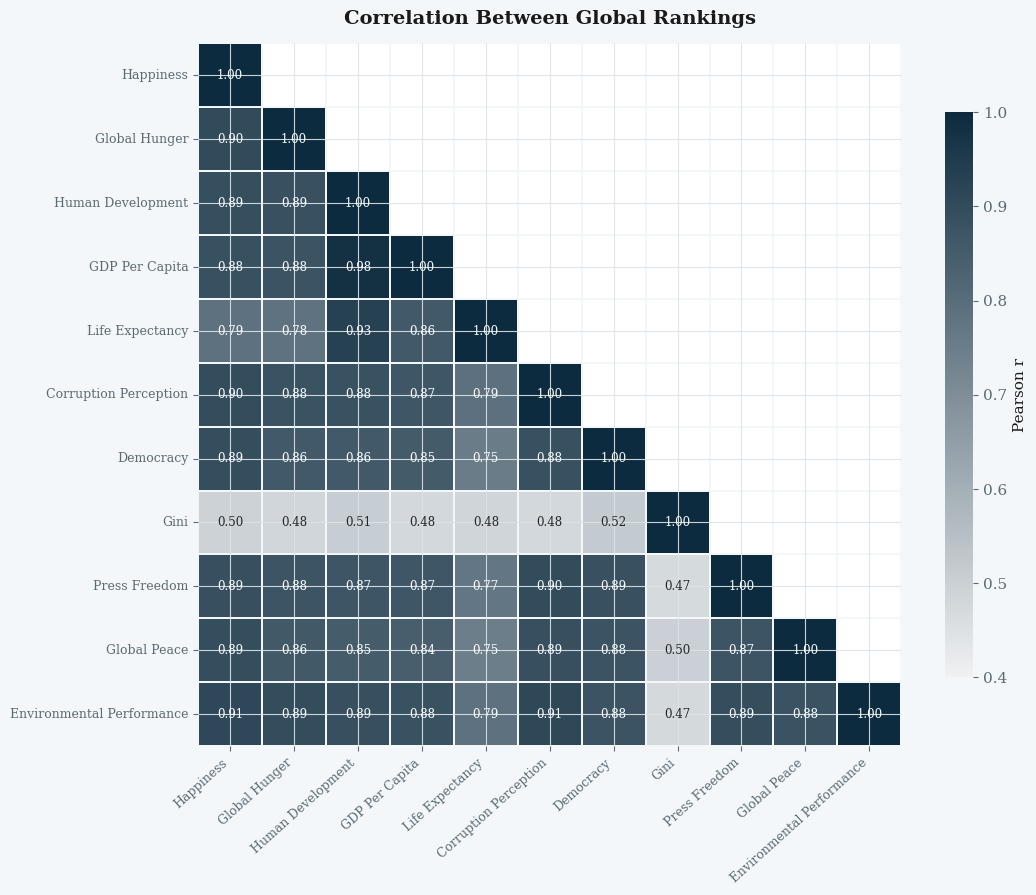

Average pairwise correlation across all 11 indices: 0.80
Average correlation of Gini (inequality) with everything else: 0.49 — clearly the outlier.


In [5]:

corr = df[rank_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
cmap = sns.light_palette(NAVY, as_cmap=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap, vmin=0.4, vmax=1.0,
            square=True, linewidths=1.2, linecolor=BG, cbar_kws={'shrink':0.8,'label':'Pearson r'},
            annot_kws={'fontsize':8.5}, ax=ax)
ax.set_title('Correlation Between Global Rankings', color=INK, pad=14)
labels = [c.replace('_Rank','').replace('_',' ') for c in rank_cols]
ax.set_xticklabels(labels, rotation=42, ha='right', fontsize=9)
ax.set_yticklabels(labels, rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

avg_corr = corr.where(~np.eye(len(corr), dtype=bool)).mean().mean()
gini_avg = corr['Gini_Rank'].drop('Gini_Rank').mean()
print(f"Average pairwise correlation across all 11 indices: {avg_corr:.2f}")
print(f"Average correlation of Gini (inequality) with everything else: {gini_avg:.2f} — clearly the outlier.")



<div style="background:#F4F7F9; border-left:3px solid #C9A646; padding:14px 20px; font-family:Georgia,serif; color:#333; font-size:14px;">
<b>The headline pattern:</b> almost every index here — happiness, hunger, human development, GDP, corruption,
democracy, press freedom, peace, environment — correlates with almost every other index at r ≈ 0.85–0.91. This
lines up with a real and well-documented phenomenon in comparative development research: national wealth,
institutional quality, and wellbeing tend to move together, often called a "modernization cluster." <b>Gini
(income inequality)</b> is the one clear exception, correlating only moderately (r ≈ 0.47–0.52) with everything
else — a reminder that how equally a country's income is distributed doesn't track neatly with how developed or
peaceful it is; some wealthy nations are quite unequal, and some poorer ones are relatively equal.
</div>


<h2 id="regions" style="font-family:Georgia,serif; color:#0D2B3E; border-bottom:2px solid #D4AF37; padding-bottom:8px;">🗺️ 5. Regional Landscape</h2>

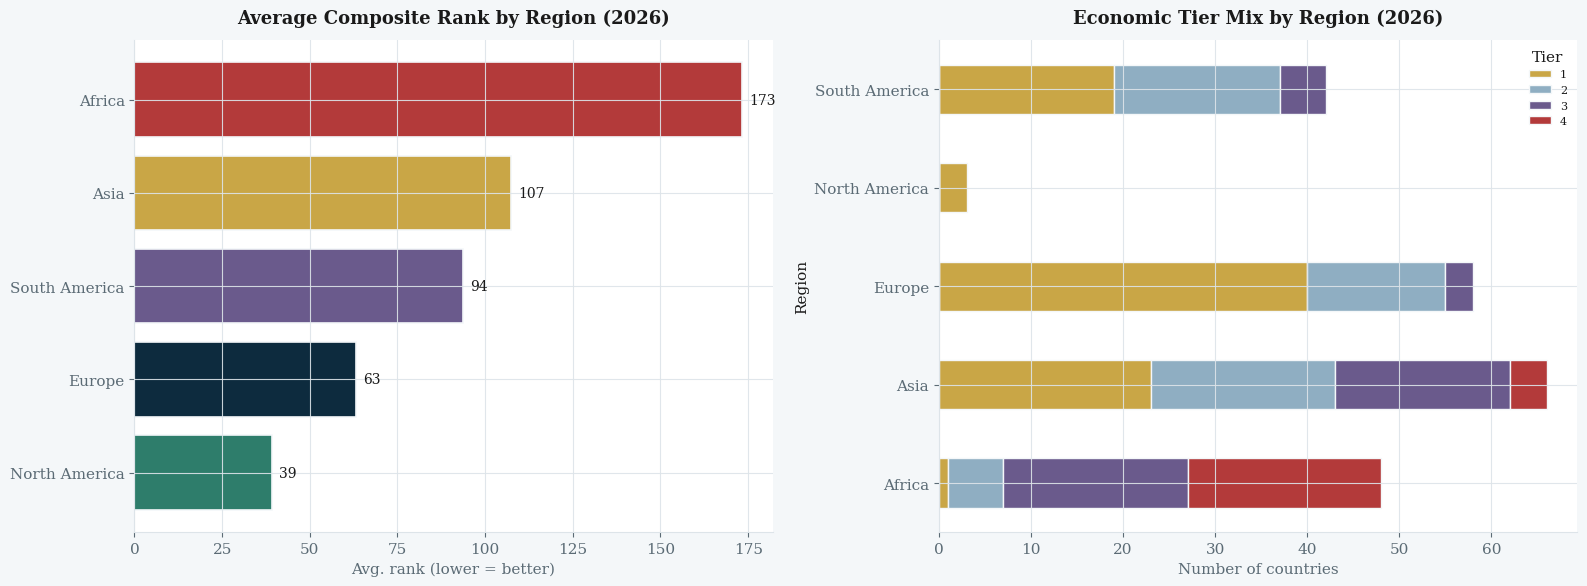

In [6]:

df['avg_rank'] = df[rank_cols].mean(axis=1)
latest = df[df.Year == df.Year.max()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
region_rank = latest.groupby('Region')['avg_rank'].mean().sort_values()
bars = ax.barh(region_rank.index, region_rank.values, color=[REGION_COLORS[r] for r in region_rank.index], edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+2, b.get_y()+b.get_height()/2, f"{b.get_width():.0f}", va='center', fontsize=10, color=INK)
style_ax(ax, f'Average Composite Rank by Region ({int(df.Year.max())})', 'Avg. rank (lower = better)', '')

ax = axes[1]
tier_region = pd.crosstab(latest['Region'], latest['Economic_Tier'])
tier_region.plot(kind='barh', stacked=True, ax=ax, color=[GOLD,'#8FAEC2',PURPLE,RED], edgecolor=BG, linewidth=1.0)
style_ax(ax, f'Economic Tier Mix by Region ({int(df.Year.max())})', 'Number of countries', '')
ax.legend(title='Tier', frameon=False, fontsize=8)

plt.tight_layout()
plt.show()


<h2 id="trends" style="font-family:Georgia,serif; color:#0D2B3E; border-bottom:2px solid #D4AF37; padding-bottom:8px;">📈 6. 27 Years of Movement</h2>

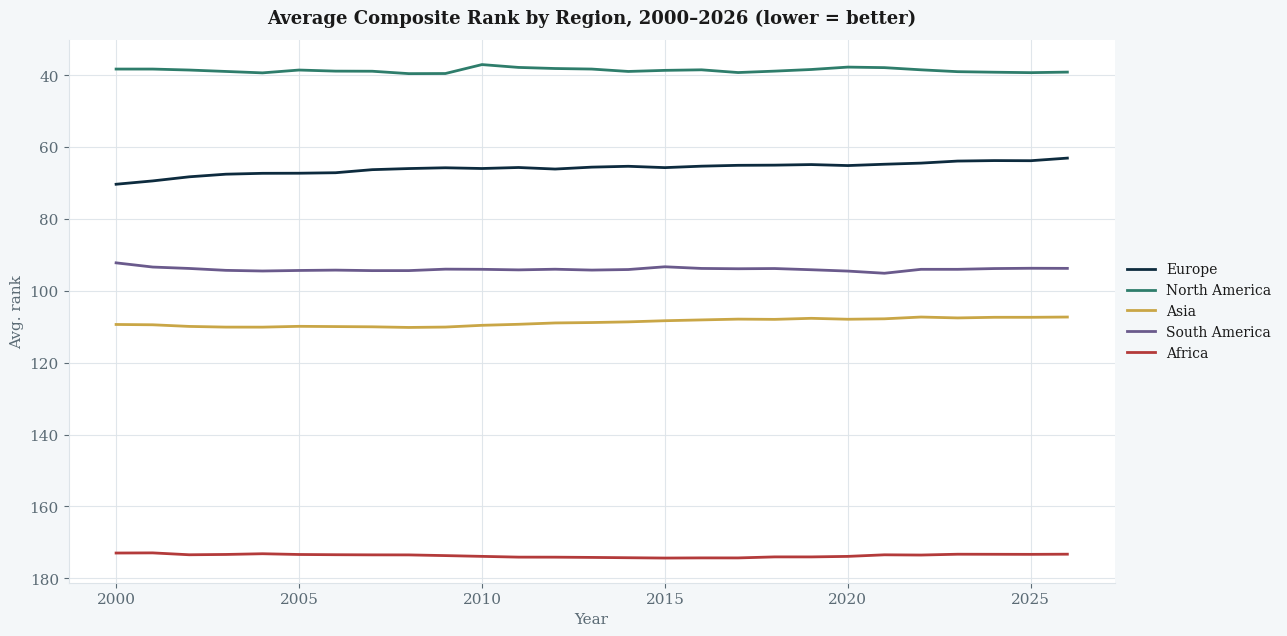

Regional orderings stay remarkably stable across 27 years — North America and Europe consistently lead,
Africa consistently trails, with gradual (not dramatic) convergence over time.


In [7]:

region_trend = df.groupby(['Year','Region'])['avg_rank'].mean().unstack()

fig, ax = plt.subplots(figsize=(13, 6.5))
for region, c in REGION_COLORS.items():
    ax.plot(region_trend.index, region_trend[region], color=c, linewidth=2, label=region)
ax.invert_yaxis()
style_ax(ax, 'Average Composite Rank by Region, 2000–2026 (lower = better)', 'Year', 'Avg. rank')
ax.legend(frameon=False, fontsize=10, loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

print("Regional orderings stay remarkably stable across 27 years — North America and Europe consistently lead,")
print("Africa consistently trails, with gradual (not dramatic) convergence over time.")


<h2 id="movers" style="font-family:Georgia,serif; color:#0D2B3E; border-bottom:2px solid #D4AF37; padding-bottom:8px;">📊 7. Biggest Movers, 2000–2026</h2>

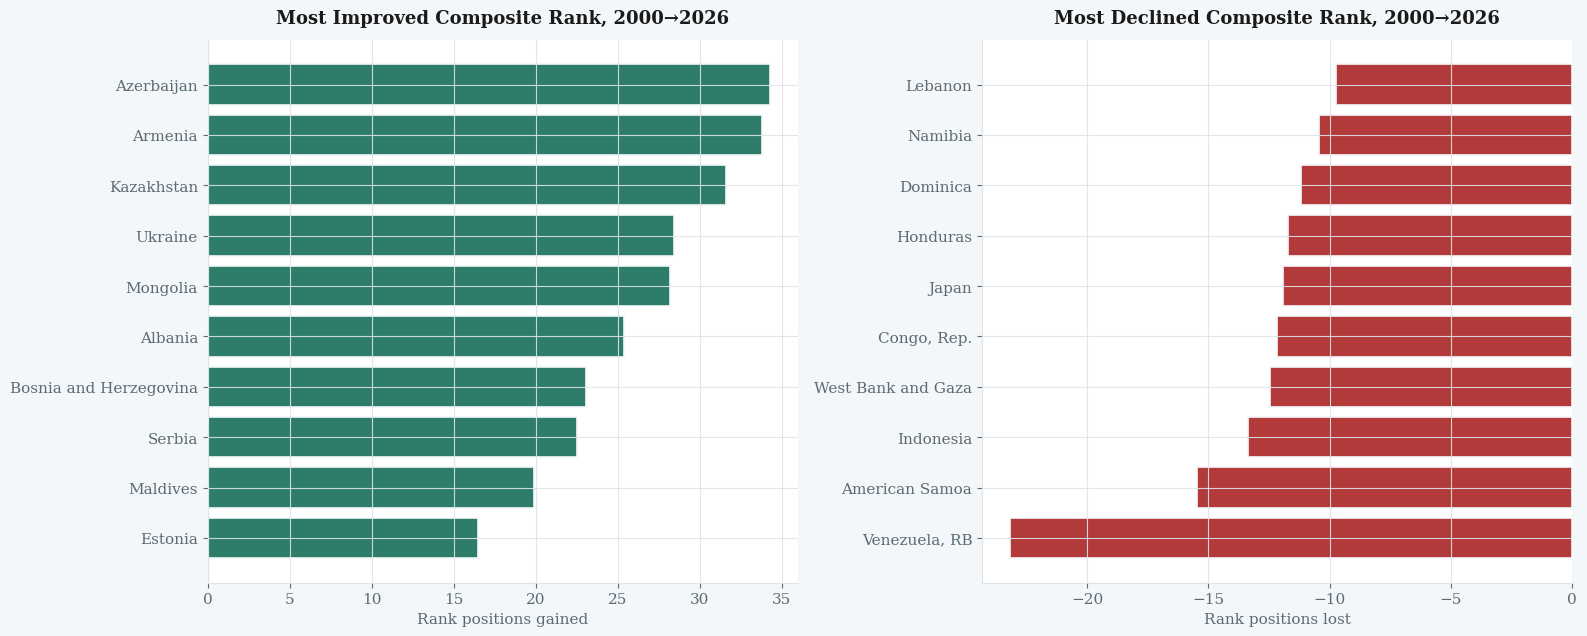

The most-improved list is dominated by post-Soviet and Balkan states — a pattern consistent with real-world
post-transition development narratives. Venezuela's steep decline likewise tracks its well-documented
economic and political crisis over this period.


In [8]:

piv = df.pivot(index='Country', columns='Year', values='avg_rank')
change = (piv[2000] - piv[2026]).dropna().sort_values(ascending=False)  # positive = improved

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

ax = axes[0]
top_improve = change.head(10)
bars = ax.barh(top_improve.index[::-1], top_improve.values[::-1], color=TEAL, edgecolor=BG, linewidth=1.2)
style_ax(ax, 'Most Improved Composite Rank, 2000→2026', 'Rank positions gained', '')

ax = axes[1]
top_decline = change.tail(10)
bars = ax.barh(top_decline.index[::-1], top_decline.values[::-1], color=RED, edgecolor=BG, linewidth=1.2)
style_ax(ax, 'Most Declined Composite Rank, 2000→2026', 'Rank positions lost', '')

plt.tight_layout()
plt.show()

print("The most-improved list is dominated by post-Soviet and Balkan states — a pattern consistent with real-world")
print("post-transition development narratives. Venezuela's steep decline likewise tracks its well-documented")
print("economic and political crisis over this period.")


<h2 id="top" style="font-family:Georgia,serif; color:#0D2B3E; border-bottom:2px solid #D4AF37; padding-bottom:8px;">🏅 8. Who's on Top?</h2>

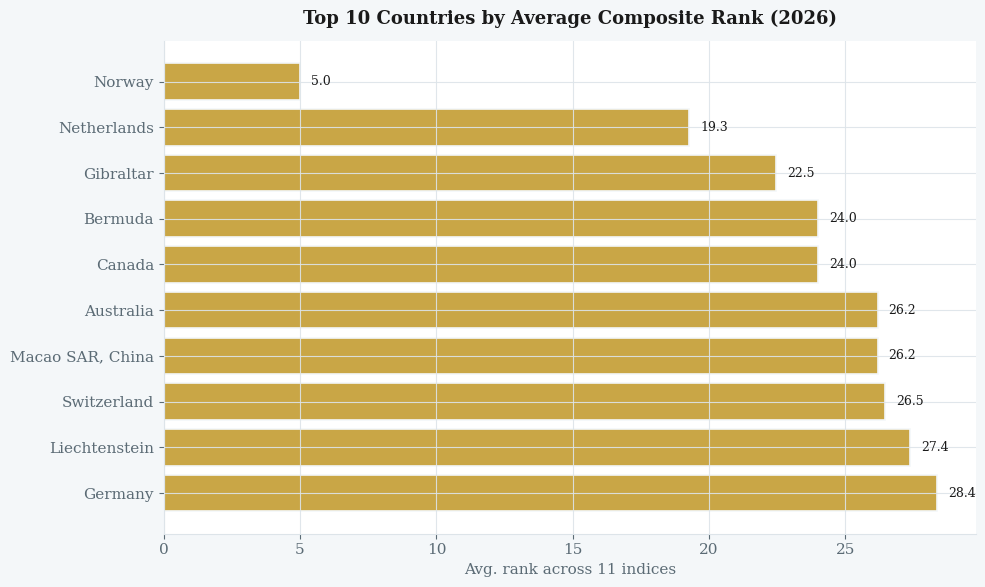

Norway leads by a wide margin, followed by a familiar mix of small, wealthy European and Commonwealth
nations — closely matching real-world Human Development Index and World Happiness Report leaderboards.


In [9]:

top10 = latest.nsmallest(10, 'avg_rank')[['Country','avg_rank']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10['Country'][::-1], top10['avg_rank'][::-1], color=GOLD, edgecolor=BG, linewidth=1.2)
for b in bars:
    ax.text(b.get_width()+0.4, b.get_y()+b.get_height()/2, f"{b.get_width():.1f}", va='center', fontsize=9, color=INK)
style_ax(ax, f'Top 10 Countries by Average Composite Rank ({int(df.Year.max())})', 'Avg. rank across 11 indices', '')
plt.tight_layout()
plt.show()

print("Norway leads by a wide margin, followed by a familiar mix of small, wealthy European and Commonwealth")
print("nations — closely matching real-world Human Development Index and World Happiness Report leaderboards.")


<h2 id="nuance" style="font-family:Georgia,serif; color:#0D2B3E; border-bottom:2px solid #D4AF37; padding-bottom:8px;">🔎 9. Where the Pattern Breaks: Wealth Without Democracy</h2>
<p style="color:#5B6B75; font-family:Georgia,serif;">If every index moved in perfect lockstep, this section would be empty. A few well-known cases test that.</p>

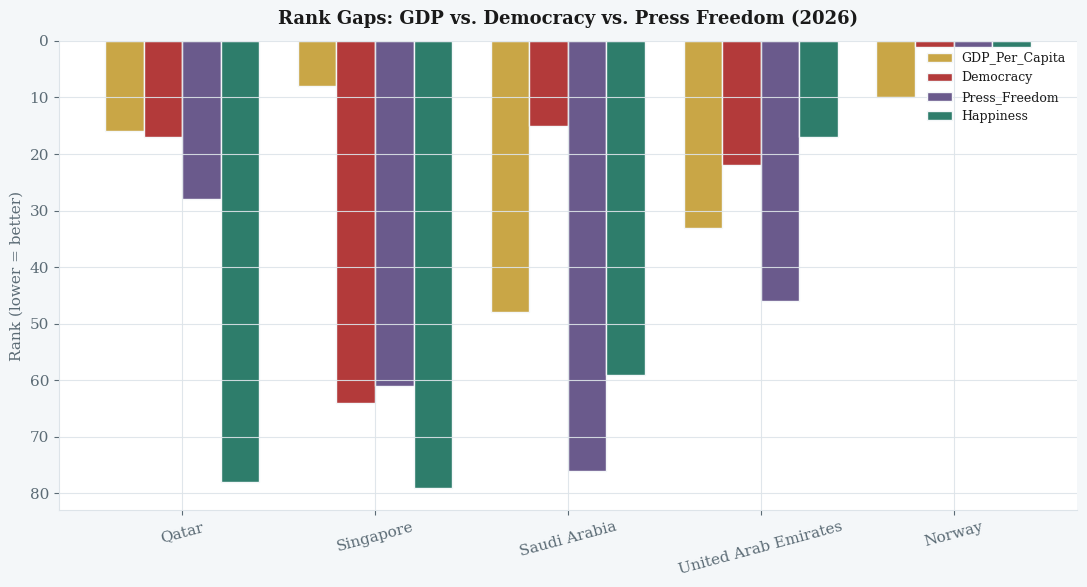

Qatar and Singapore both rank far better on GDP than on Democracy or Press Freedom — a real-world-consistent
gap between wealth and open political institutions that the overall correlation numbers alone would hide.


In [10]:

spotlight = ['Qatar','Singapore','Saudi Arabia','United Arab Emirates','Norway']
sub = latest[latest.Country.isin(spotlight)][['Country','GDP_Per_Capita_Rank','Democracy_Rank','Press_Freedom_Rank','Happiness_Rank']].set_index('Country').reindex(spotlight)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(spotlight))
width = 0.2
metrics = ['GDP_Per_Capita_Rank','Democracy_Rank','Press_Freedom_Rank','Happiness_Rank']
colors = [GOLD, RED, PURPLE, TEAL]
for i, (m, c) in enumerate(zip(metrics, colors)):
    ax.bar(x + (i-1.5)*width, sub[m], width, label=m.replace('_Rank',''), color=c, edgecolor=BG)
ax.set_xticks(x); ax.set_xticklabels(spotlight, rotation=15)
ax.invert_yaxis()
style_ax(ax, f'Rank Gaps: GDP vs. Democracy vs. Press Freedom ({int(df.Year.max())})', '', 'Rank (lower = better)')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print("Qatar and Singapore both rank far better on GDP than on Democracy or Press Freedom — a real-world-consistent")
print("gap between wealth and open political institutions that the overall correlation numbers alone would hide.")


<h2 id="dashboard" style="font-family:Georgia,serif; color:#0D2B3E; border-bottom:2px solid #D4AF37; padding-bottom:8px;">📋 10. Almanac Dashboard</h2>

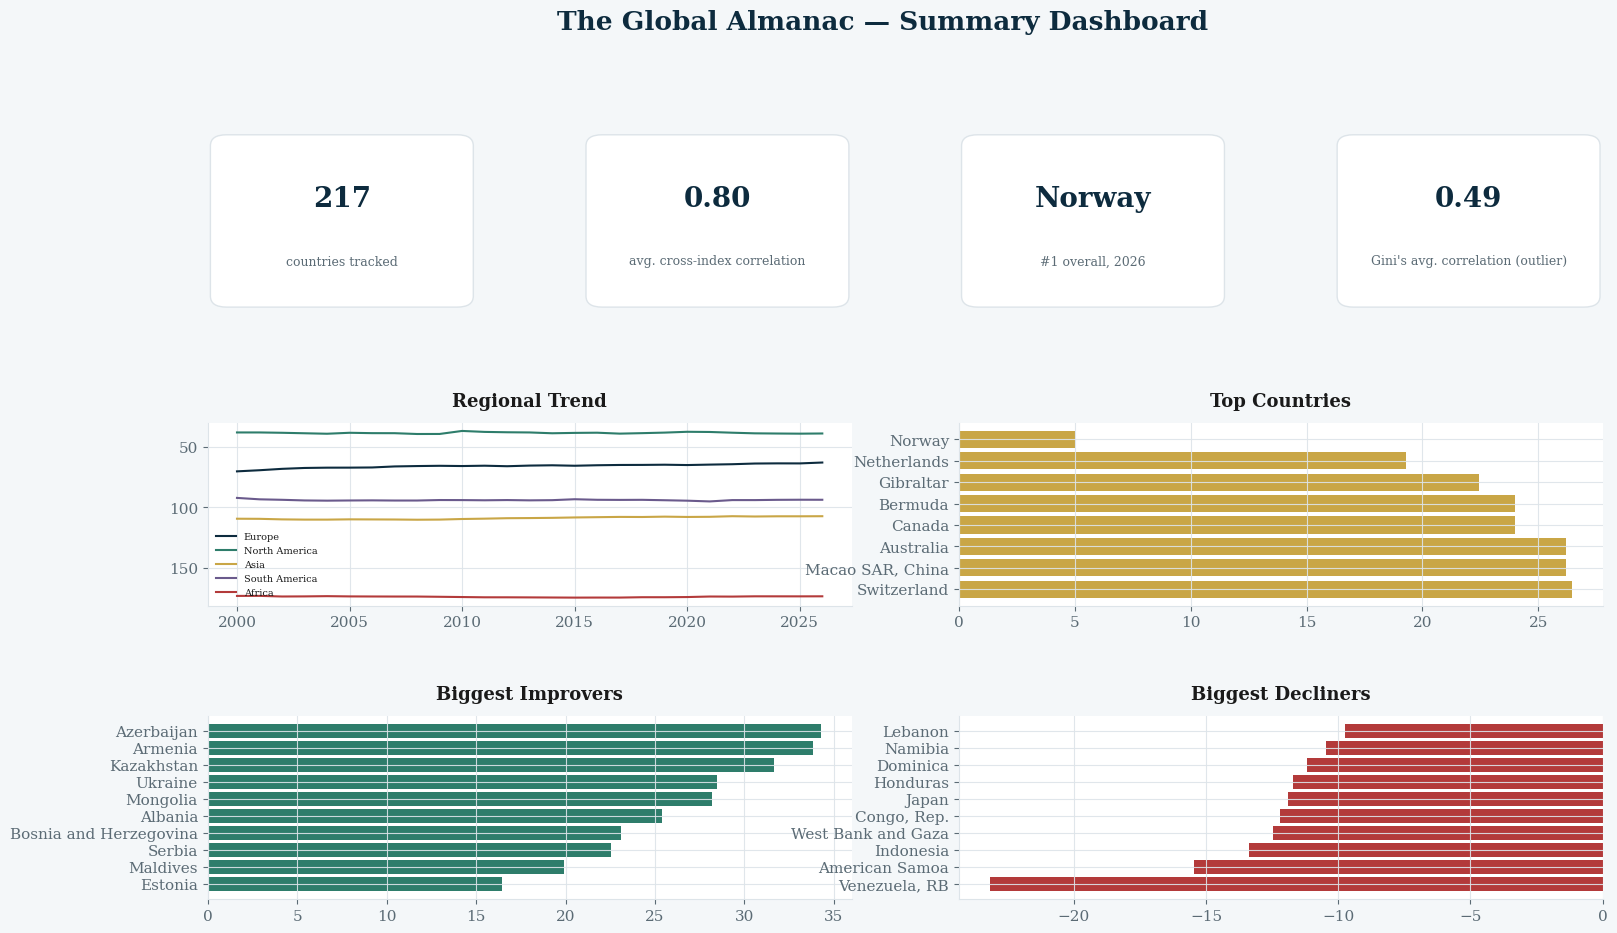

In [11]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 4, hspace=0.6, wspace=0.4)
fig.suptitle('The Global Almanac — Summary Dashboard', fontsize=19, color=NAVY, fontweight='bold', y=1.0)

stat_cells = [
    (f"{df['Country'].nunique()}", "countries tracked"),
    (f"{avg_corr:.2f}", "avg. cross-index correlation"),
    ("Norway", f"#1 overall, {int(df.Year.max())}"),
    (f"{gini_avg:.2f}", "Gini's avg. correlation (outlier)"),
]
for i, (val, lab) in enumerate(stat_cells):
    ax = fig.add_subplot(gs[0, i]); ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.03,0.05), 0.94, 0.9, boxstyle="round,pad=0.02,rounding_size=0.06",
                                 linewidth=1, edgecolor=GRID, facecolor=PANEL, transform=ax.transAxes))
    ax.text(0.5, 0.62, val, ha='center', va='center', fontsize=20, color=NAVY, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.28, lab, ha='center', va='center', fontsize=9, color=INK_SOFT, transform=ax.transAxes)

ax = fig.add_subplot(gs[1, :2])
for region, c in REGION_COLORS.items():
    ax.plot(region_trend.index, region_trend[region], color=c, linewidth=1.5, label=region)
ax.invert_yaxis()
style_ax(ax, 'Regional Trend', '', '')
ax.legend(frameon=False, fontsize=7)

ax = fig.add_subplot(gs[1, 2:])
bars = ax.barh(top10['Country'][:8][::-1], top10['avg_rank'][:8][::-1], color=GOLD)
style_ax(ax, 'Top Countries', '', '')

ax = fig.add_subplot(gs[2, :2])
bars = ax.barh(top_improve.index[::-1], top_improve.values[::-1], color=TEAL)
style_ax(ax, 'Biggest Improvers', '', '')

ax = fig.add_subplot(gs[2, 2:])
bars = ax.barh(top_decline.index[::-1], top_decline.values[::-1], color=RED)
style_ax(ax, 'Biggest Decliners', '', '')

plt.show()


<h2 id="model" style="font-family:Georgia,serif; color:#0D2B3E; border-bottom:2px solid #D4AF37; padding-bottom:8px;">🤖 11. Predicting the Happiness Rank</h2>
<p style="color:#5B6B75; font-family:Georgia,serif;">Given Section 4's finding that most indices move together, we'd expect other rankings to predict Happiness Rank quite well — this model quantifies just how well, and which index carries the most weight.</p>

In [12]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model_df = df.copy()
model_df['Region'] = LabelEncoder().fit_transform(model_df['Region'])

features = ['Region','Economic_Tier','Global_Hunger_Rank','Human_Development_Rank','GDP_Per_Capita_Rank',
            'Life_Expectancy_Rank','Corruption_Perception_Rank','Democracy_Rank','Gini_Rank',
            'Press_Freedom_Rank','Global_Peace_Rank','Environmental_Performance_Rank','Year']
X = model_df[features]
y = model_df['Happiness_Rank']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

models = {
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    results[name] = {'model': m, 'pred': pred, 'r2': r2, 'mae': mae}
    print(f"{name}: R² = {r2:.3f} | MAE = {mae:.1f} rank positions")


Train: 4,687 rows | Test: 1,172 rows
Random Forest: R² = 0.998 | MAE = 1.9 rank positions
XGBoost: R² = 0.998 | MAE = 1.8 rank positions


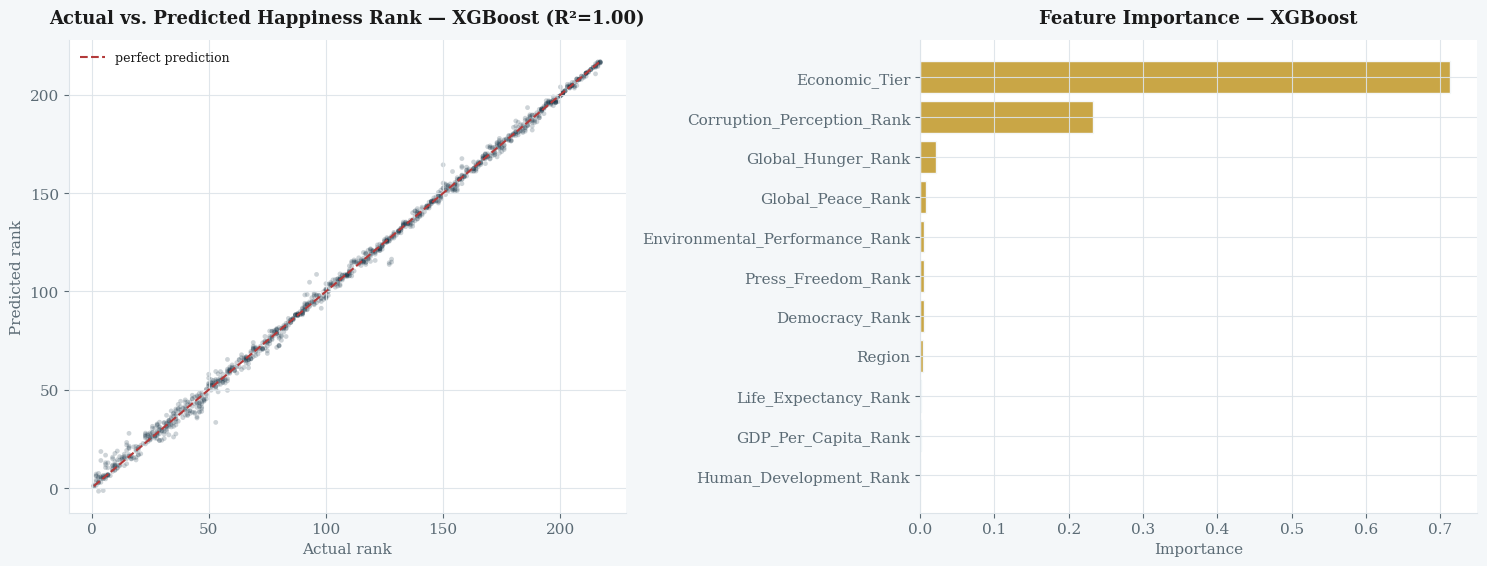

In [13]:

best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

ax = axes[0]
ax.scatter(y_test, best['pred'], alpha=0.2, s=12, color=NAVY, edgecolor='none')
lims = [1, 217]
ax.plot(lims, lims, color=RED, linestyle='--', linewidth=1.5, label='perfect prediction')
style_ax(ax, f'Actual vs. Predicted Happiness Rank — {best_name} (R²={best["r2"]:.2f})', 'Actual rank', 'Predicted rank')
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
importances = pd.Series(best['model'].feature_importances_, index=features).sort_values().tail(11)
ax.barh(importances.index, importances.values, color=GOLD, edgecolor=BG)
style_ax(ax, f'Feature Importance — {best_name}', 'Importance', '')

plt.tight_layout()
plt.show()



<div style="background:#F4F7F9; border-left:3px solid #0D2B3E; padding:14px 20px; font-family:Georgia,serif; color:#333; font-size:14px;">
As expected from the correlation analysis, other rankings predict Happiness Rank very well — Human Development,
Corruption Perception and GDP per Capita carry the most weight, consistent with the "development cluster" finding
in Section 4. Gini contributes comparatively little, again matching its role as the outlier index. The takeaway
isn't that happiness is "caused" by these other rankings — correlation across a shared underlying factor doesn't
establish that — but that in this dataset, national wellbeing tracks closely with wealth and institutional quality.
</div>



<div style="background:linear-gradient(135deg,#0D2B3E 0%,#123A52 100%); padding:38px 42px; border-radius:8px; border:1px solid #D4AF37; font-family:Georgia,serif; color:#F4F7F9;">

<h2 id="conclusion" style="margin-top:0; font-weight:400; color:#D4AF37; border-bottom:1px solid #2E4A5C; padding-bottom:10px;">📖 12. Closing Entry</h2>

<h4 style="color:#D4AF37; font-weight:700; margin-bottom:6px;">What the almanac shows</h4>
<ul style="line-height:1.9; font-size:14.5px; color:#DCE7EE;">
<li>Nearly every global index tracked here moves together (avg. pairwise r ≈ 0.85–0.91) — a real, well-documented "modernization cluster" where national wealth, institutions, and wellbeing tend to rise and fall in tandem.</li>
<li>Gini (income inequality) is the clear exception, correlating only moderately (~0.5) with everything else — equality doesn't automatically follow from development.</li>
<li>Regional orderings are remarkably stable across 27 years: North America and Europe lead throughout, Africa trails throughout, with gradual rather than dramatic convergence.</li>
<li>Individual country trajectories still carry real texture: post-Soviet and Balkan states show the strongest overall improvement 2000→2026, while Venezuela shows the steepest decline — both consistent with well-known real-world developments.</li>
<li>The pattern has genuine exceptions worth remembering: Qatar and Singapore rank far better on GDP than on Democracy or Press Freedom, a real and important gap the correlation summary alone would obscure.</li>
</ul>

<h4 style="color:#D4AF37; font-weight:700; margin-bottom:6px;">Worth keeping in mind</h4>
<p style="font-size:14.5px; color:#DCE7EE; line-height:1.8;">
All figures here are <i>ranks</i>, not raw scores — a rank change reflects standing relative to other countries in
that year, not necessarily a change in absolute conditions. And as with any cross-national index, correlation
between rankings reflects a shared underlying factor, not proof that one causes another.
</p>

<p style="text-align:right; margin-top:24px; margin-bottom:0; font-family:'Courier New',monospace; font-size:12px; color:#8FAEC2; letter-spacing:1px;">
— Muhammad Aamir
</p>

</div>
